In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [6]:
import numpy as np
print(np.__version__)

2.5.1


In [7]:
import nnunetv2
print("nnU-Net imported successfully!")

nnU-Net imported successfully!


In [8]:
import os

base = "/content/nnUNet"

os.environ["nnUNet_raw"] = os.path.join(base, "nnUNet_raw")
os.environ["nnUNet_preprocessed"] = os.path.join(base, "nnUNet_preprocessed")
os.environ["nnUNet_results"] = os.path.join(base, "nnUNet_results")

os.makedirs(os.environ["nnUNet_raw"], exist_ok=True)
os.makedirs(os.environ["nnUNet_preprocessed"], exist_ok=True)
os.makedirs(os.environ["nnUNet_results"], exist_ok=True)

print("✅ nnU-Net directories created!")

✅ nnU-Net directories created!


In [9]:
dataset_id = "Dataset001_Mammogram"

dataset_path = os.path.join(
    os.environ["nnUNet_raw"],
    dataset_id
)

imagesTr = os.path.join(dataset_path, "imagesTr")
labelsTr = os.path.join(dataset_path, "labelsTr")

os.makedirs(imagesTr, exist_ok=True)
os.makedirs(labelsTr, exist_ok=True)

print(imagesTr)
print(labelsTr)

/content/nnUNet/nnUNet_raw/Dataset001_Mammogram/imagesTr
/content/nnUNet/nnUNet_raw/Dataset001_Mammogram/labelsTr


In [2]:
!pip install -U nnunetv2
!pip install SimpleITK
!pip install nibabel

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [3]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
X = np.load("/content/drive/MyDrive/Mammogram_Project/NEW_ROI_X.npy")
Y = np.load("/content/drive/MyDrive/Mammogram_Project/NEW_ROI_Y.npy")

print(X.shape)
print(Y.shape)

(3242, 128, 128, 1)
(3242, 128, 128, 1)


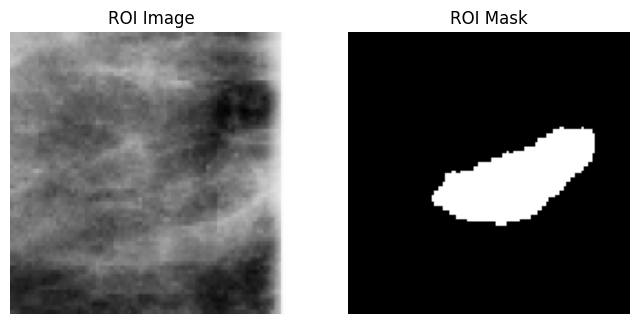

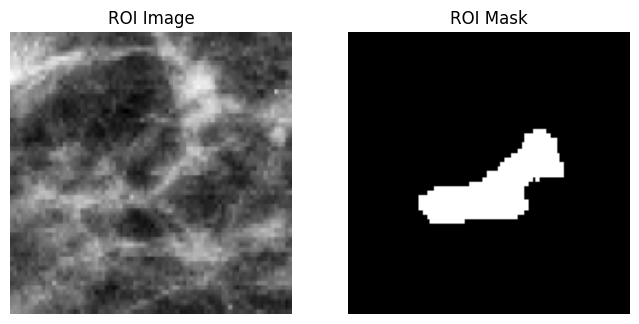

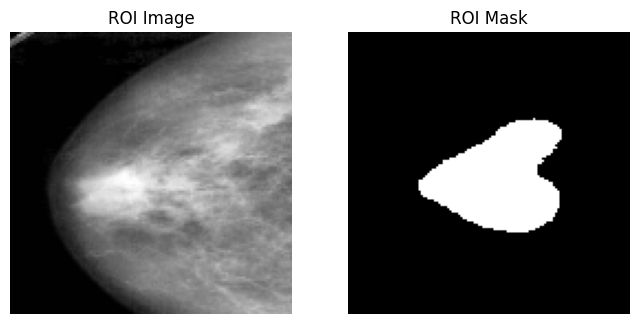

In [10]:
import matplotlib.pyplot as plt

for i in range(3):

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(X[i].squeeze(), cmap='gray')
    plt.title("ROI Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(Y[i].squeeze(), cmap='gray')
    plt.title("ROI Mask")
    plt.axis("off")

    plt.show()

In [11]:
import os
import SimpleITK as sitk
from tqdm import tqdm

print("Converting ROI images to nnU-Net format...")

for i in tqdm(range(len(X))):

    # -----------------------
    # Image
    # -----------------------
    img = X[i].squeeze().astype(np.float32)

    # Add z-dimension (1,128,128)
    img = img[np.newaxis, :, :]

    img_itk = sitk.GetImageFromArray(img)

    sitk.WriteImage(
        img_itk,
        os.path.join(
            imagesTr,
            f"case_{i:04d}_0000.nii.gz"
        )
    )

    # -----------------------
    # Mask
    # -----------------------
    mask = Y[i].squeeze().astype(np.uint8)

    mask = mask[np.newaxis, :, :]

    mask_itk = sitk.GetImageFromArray(mask)

    sitk.WriteImage(
        mask_itk,
        os.path.join(
            labelsTr,
            f"case_{i:04d}.nii.gz"
        )
    )

print("✅ All files converted successfully!")

Converting ROI images to nnU-Net format...


100%|██████████| 3242/3242 [00:12<00:00, 255.91it/s]

✅ All files converted successfully!


In [12]:
print("Images :", len(os.listdir(imagesTr)))
print("Masks  :", len(os.listdir(labelsTr)))

Images : 3242
Masks  : 3242


In [13]:
import json
import os

dataset_json = {

    "channel_names": {
        "0": "Grayscale"
    },

    "labels": {
        "background": 0,
        "lesion": 1
    },

    "numTraining": 3242,

    "file_ending": ".nii.gz"

}

json_path = os.path.join(dataset_path, "dataset.json")

with open(json_path, "w") as f:
    json.dump(dataset_json, f, indent=4)

print("✅ dataset.json created!")

✅ dataset.json created!


In [14]:
with open(json_path) as f:
    print(f.read())

{
    "channel_names": {
        "0": "Grayscale"
    },
    "labels": {
        "background": 0,
        "lesion": 1
    },
    "numTraining": 3242,
    "file_ending": ".nii.gz"
}


In [16]:
import os

print(dataset_path)
print(imagesTr)
print(labelsTr)

/content/nnUNet/nnUNet_raw/Dataset001_Mammogram
/content/nnUNet/nnUNet_raw/Dataset001_Mammogram/imagesTr
/content/nnUNet/nnUNet_raw/Dataset001_Mammogram/labelsTr


In [15]:
print(os.environ["nnUNet_raw"])
print(os.environ["nnUNet_preprocessed"])
print(os.environ["nnUNet_results"])

/content/nnUNet/nnUNet_raw
/content/nnUNet/nnUNet_preprocessed
/content/nnUNet/nnUNet_results


In [17]:
!nnUNetv2_plan_and_preprocess \
-d 1 \
-c 2d \
--verify_dataset_integrity

Fingerprint extraction...
Dataset001_Mammogram
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Extracting dataset fingerprint: 100% 3242/3242 [00:42<00:00, 76.13it/s] 
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 162, 'patch_size': (np.int64(128), np.int64(128)), 'median_image_size_in_voxels': array([128., 128.]), 'spacing': array([1., 1.]), 'n

In [18]:
!nnUNetv2_train 1 2d 0


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-07-05 14:28:42.763185: Using torch.compile...
2026-07-05 14:28:46.047240: do_dummy_2d_data_aug: False
2026-07-05 14:28:46.062952: Creating new 5-fold cross-validation split...
2026-07-05 14:28:46.103614: Desired fold for training: 0
2026-07-05 14:28:46.103806: This split has 2593 training a

In [19]:
import os

results_dir = os.environ["nnUNet_results"]

for root, dirs, files in os.walk(results_dir):
    for f in files:
        if f.endswith(".pth"):
            print(os.path.join(root, f))

/content/nnUNet/nnUNet_results/Dataset001_Mammogram/nnUNetTrainer__nnUNetPlans__2d/fold_0/checkpoint_best.pth


In [22]:
from sklearn.model_selection import train_test_split

train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

[array([[[[0.00784314],
          [0.00784314],
          [0.00784314],
          ...,
          [0.24313726],
          [0.2788411 ],
          [0.28235295]],
 
         [[0.00784314],
          [0.00784314],
          [0.00784314],
          ...,
          [0.24575165],
          [0.28066206],
          [0.28409588]],
 
         [[0.00784314],
          [0.00784314],
          [0.00784314],
          ...,
          [0.25490198],
          [0.2870354 ],
          [0.2901961 ]],
 
         ...,
 
         [[0.57254905],
          [0.5616623 ],
          [0.4509804 ],
          ...,
          [0.6509804 ],
          [0.6795435 ],
          [0.68235296]],
 
         [[0.51459694],
          [0.5151823 ],
          [0.52113295],
          ...,
          [0.6143791 ],
          [0.62905735],
          [0.6305011 ]],
 
         [[0.49803922],
          [0.5019023 ],
          [0.5411765 ],
          ...,
          [0.6039216 ],
          [0.6146327 ],
          [0.6156863 ]]],
 
 
        [

In [23]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.load("/content/drive/MyDrive/Mammogram_Project/NEW_ROI_X.npy")
Y = np.load("/content/drive/MyDrive/Mammogram_Project/NEW_ROI_Y.npy")

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print(X_test.shape)

(325, 128, 128, 1)


In [24]:
import os

test_folder = "/content/nnUNet/test_images"

os.makedirs(test_folder, exist_ok=True)

In [25]:
import SimpleITK as sitk
from tqdm import tqdm

for i in tqdm(range(len(X_test))):

    img = X_test[i].squeeze().astype(np.float32)
    img = img[np.newaxis, :, :]

    img_itk = sitk.GetImageFromArray(img)

    sitk.WriteImage(
        img_itk,
        os.path.join(
            test_folder,
            f"case_{i:04d}_0000.nii.gz"
        )
    )

print("Done!")

100%|██████████| 325/325 [00:00<00:00, 379.97it/s]

Done!


In [26]:
!nnUNetv2_predict \
-i /content/nnUNet/test_images \
-o /content/nnUNet/predictions \
-d 1 \
-c 2d \
-f 0 \
-chk checkpoint_best.pth


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 325 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 325 cases that I would like to predict

Predicting case_0000:
perform_everything_on_device: True
100% 1/1 [00:01<00:00,  1.55s/it]
sending off prediction to background worker for resampling and export
done with case_0000

Predicting case_0001:
perform_everything_on_device: True
100% 1/1 [00:00<00:00,  8.07it/s]
sending off prediction to background worker for resampling and export
done with case_0001

Predicting case_0002:
perform_everything_on_device: True
100% 1/1 [00

In [27]:
import os

pred_dir = "/content/nnUNet/predictions"

print("Number of predictions:", len(os.listdir(pred_dir)))

print(os.listdir(pred_dir)[:5])

Number of predictions: 328
['case_0074.nii.gz', 'case_0097.nii.gz', 'case_0094.nii.gz', 'case_0281.nii.gz', 'case_0275.nii.gz']


In [28]:
import os
import SimpleITK as sitk
import numpy as np

predictions = []

for i in range(len(X_test)):

    pred = sitk.GetArrayFromImage(
        sitk.ReadImage(
            os.path.join(
                pred_dir,
                f"case_{i:04d}.nii.gz"
            )
        )
    )

    pred = pred.squeeze()

    predictions.append(pred)

predictions = np.array(predictions)

print(predictions.shape)

(325, 128, 128)


In [29]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Ensure binary masks
y_true = (Y_test.squeeze() > 0).astype(np.uint8)
y_pred = (predictions > 0).astype(np.uint8)

dice_scores = []
iou_scores = []

acc_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for gt, pred in zip(y_true, y_pred):

    gt_flat = gt.flatten()
    pred_flat = pred.flatten()

    # Dice
    intersection = np.sum(gt_flat * pred_flat)
    dice = (2 * intersection + 1e-6) / (
        np.sum(gt_flat) + np.sum(pred_flat) + 1e-6
    )

    # IoU
    union = np.sum(gt_flat) + np.sum(pred_flat) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)

    # Accuracy
    acc = accuracy_score(gt_flat, pred_flat)

    # Precision
    prec = precision_score(
        gt_flat,
        pred_flat,
        zero_division=0
    )

    # Recall
    rec = recall_score(
        gt_flat,
        pred_flat,
        zero_division=0
    )

    # F1
    f1 = f1_score(
        gt_flat,
        pred_flat,
        zero_division=0
    )

    dice_scores.append(dice)
    iou_scores.append(iou)
    acc_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)

print("="*40)
print("nnU-Net Test Results")
print("="*40)

print(f"Dice Score : {np.mean(dice_scores):.4f}")
print(f"IoU        : {np.mean(iou_scores):.4f}")
print(f"Accuracy   : {np.mean(acc_scores):.4f}")
print(f"Precision  : {np.mean(precision_scores):.4f}")
print(f"Recall     : {np.mean(recall_scores):.4f}")
print(f"F1 Score   : {np.mean(f1_scores):.4f}")

nnU-Net Test Results
Dice Score : 0.8989
IoU        : 0.8294
Accuracy   : 0.9880
Precision  : 0.8933
Recall     : 0.9180
F1 Score   : 0.8989


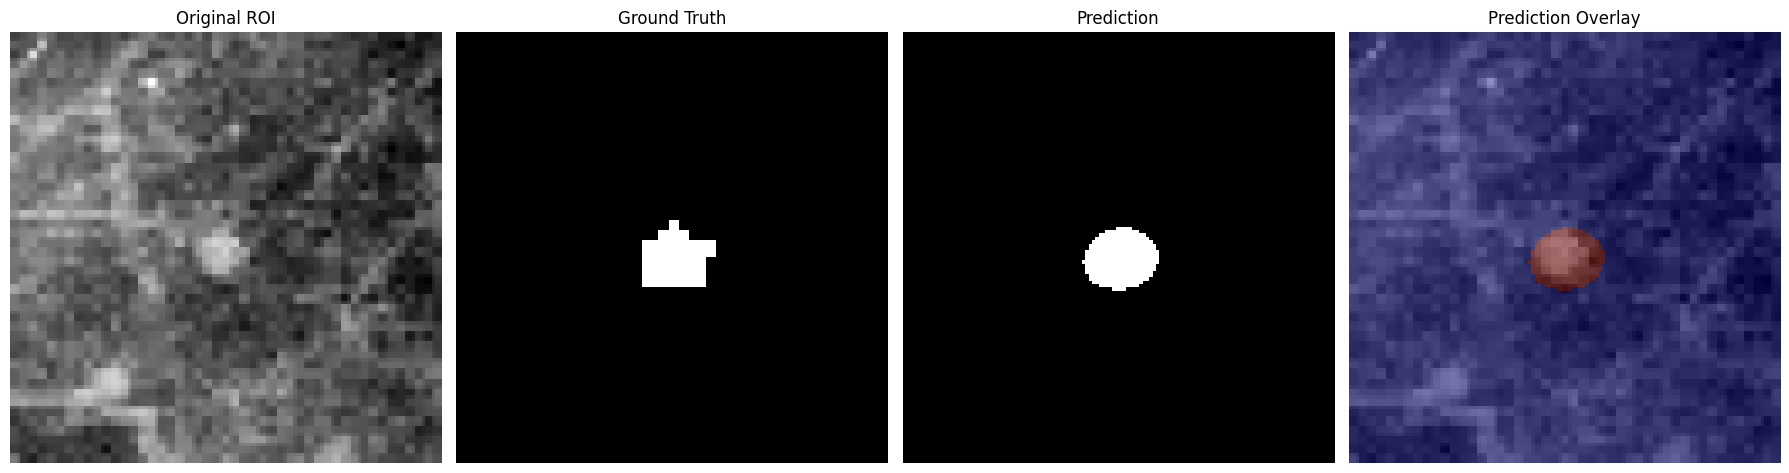

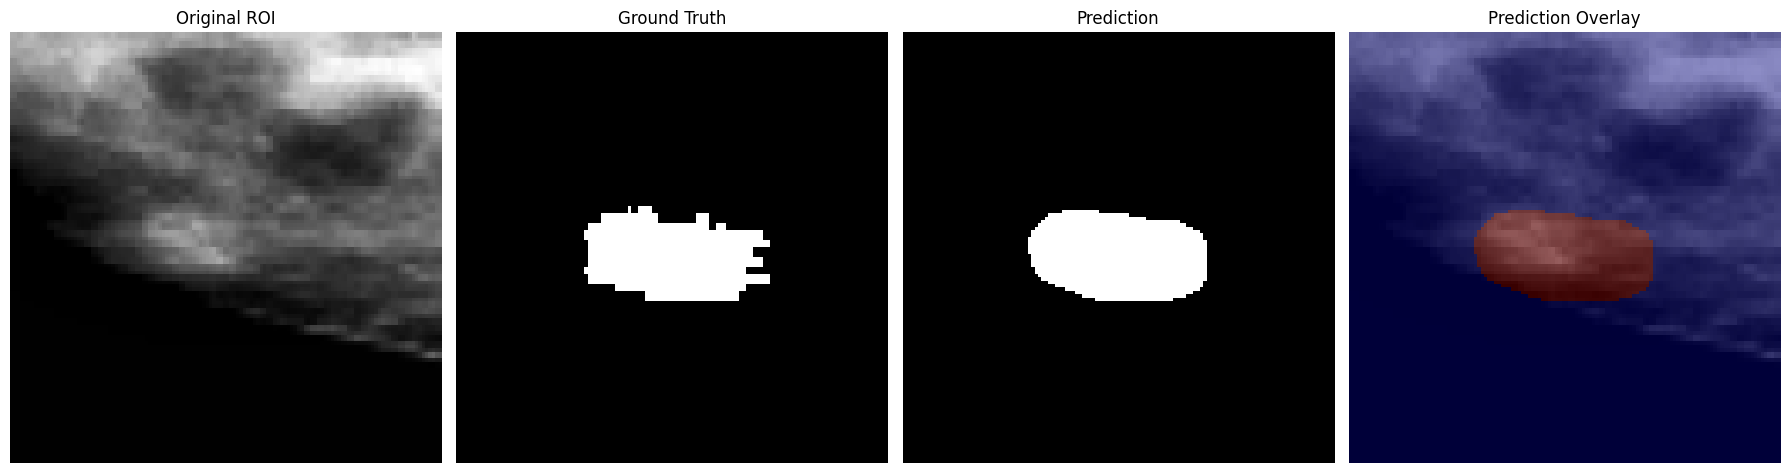

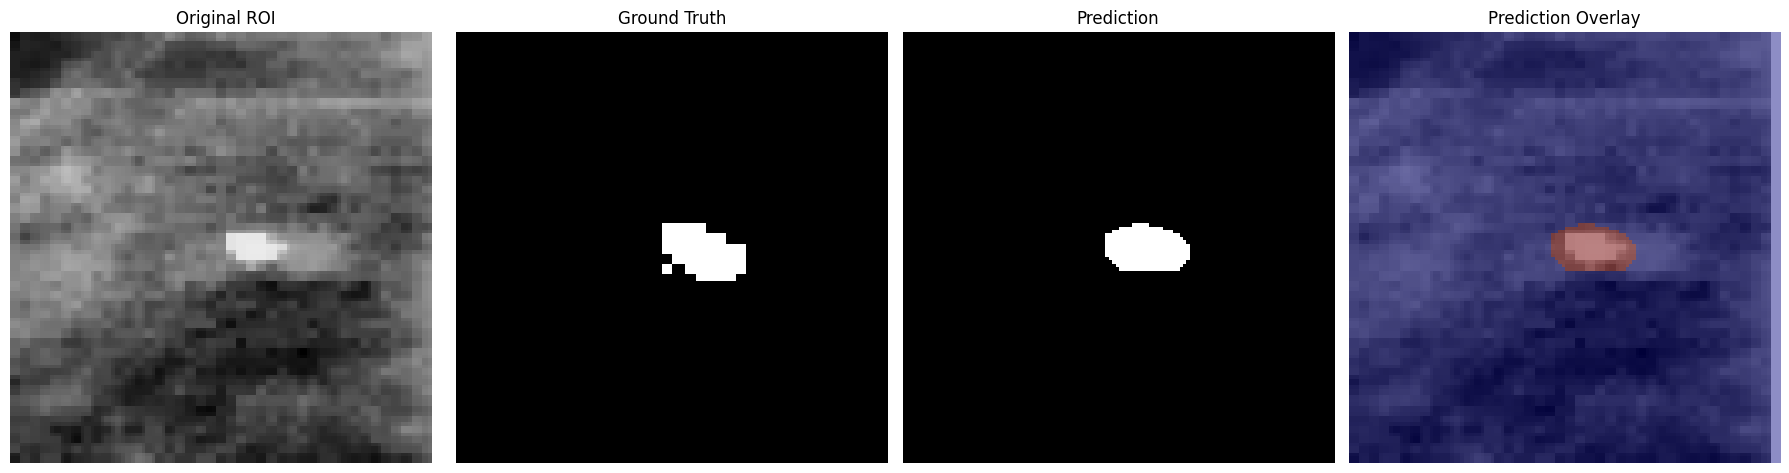

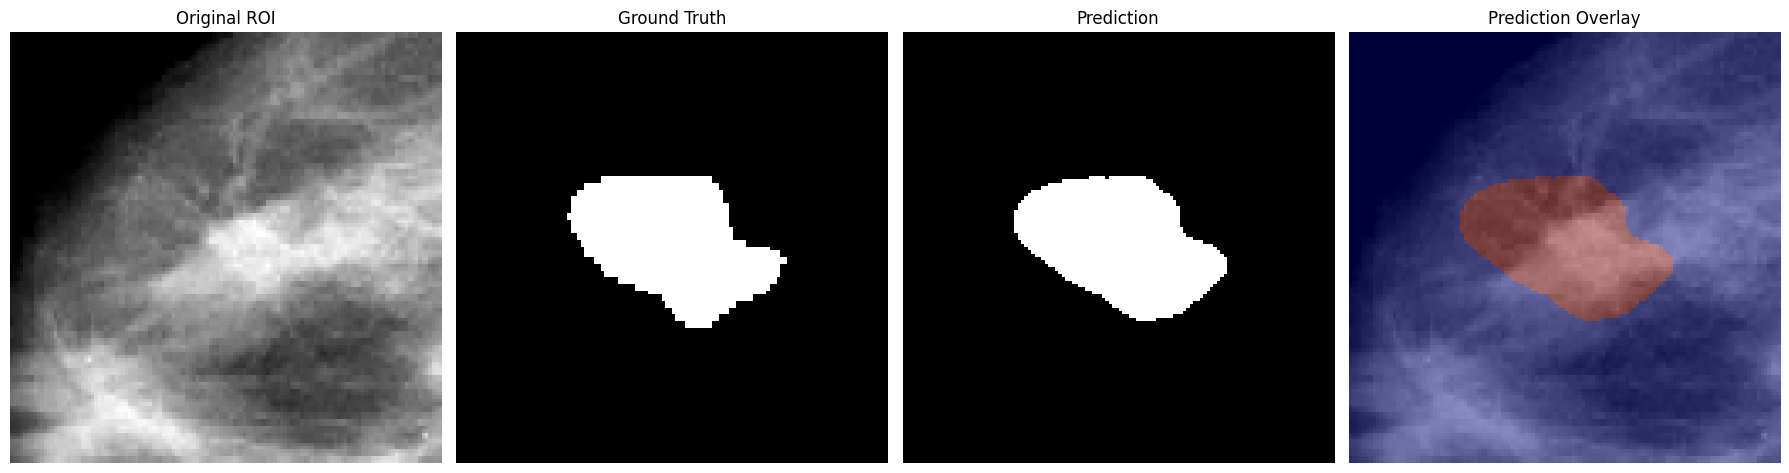

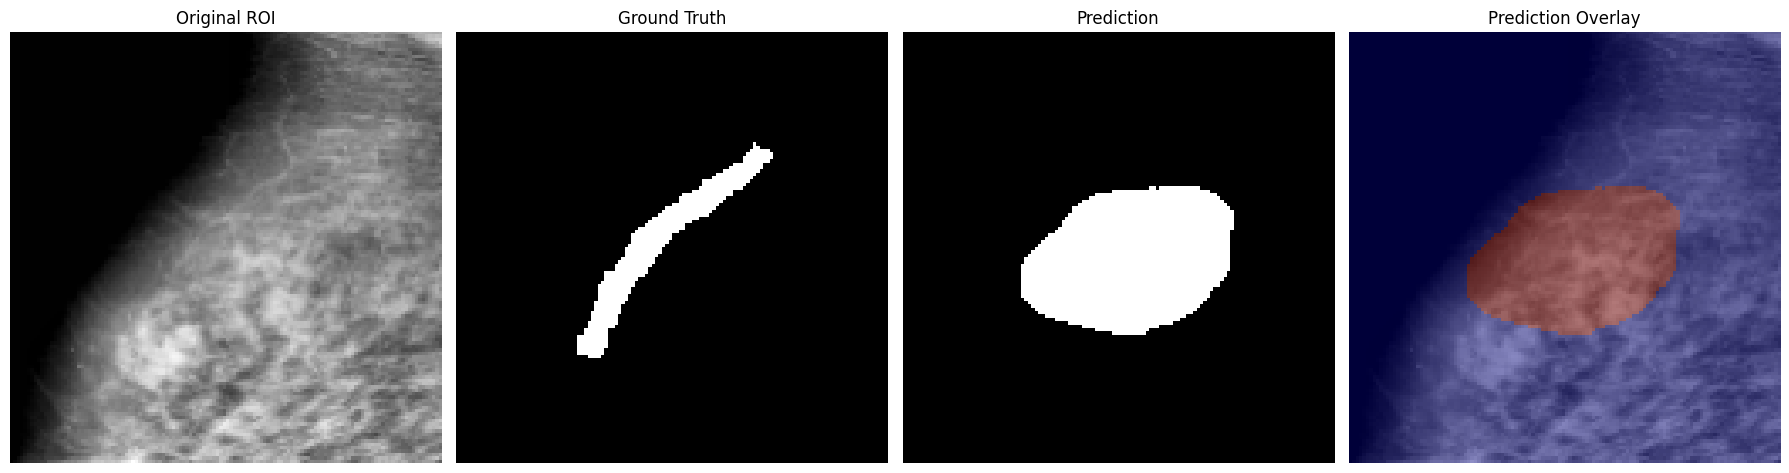

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Number of examples to display
num_samples = 5

indices = random.sample(range(len(X_test)), num_samples)

for idx in indices:

    img = X_test[idx].squeeze()
    gt = Y_test[idx].squeeze()
    pred = predictions[idx]

    pred = (pred > 0).astype(np.uint8)

    plt.figure(figsize=(18,5))

    # Original ROI
    plt.subplot(1,4,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original ROI")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,4,2)
    plt.imshow(gt, cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1,4,3)
    plt.imshow(pred, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    # Overlay
    plt.subplot(1,4,4)
    plt.imshow(img, cmap='gray')
    plt.imshow(pred, cmap='jet', alpha=0.45)
    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

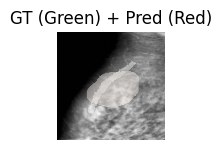

In [36]:
plt.subplot(1,4,4)

plt.imshow(img, cmap='gray')

# Ground Truth (Green)
plt.imshow(
    np.ma.masked_where(gt == 0, gt),
    cmap='Greens',
    alpha=0.4
)

# Prediction (Red)
plt.imshow(
    np.ma.masked_where(pred == 0, pred),
    cmap='Reds',
    alpha=0.4
)

plt.title("GT (Green) + Pred (Red)")
plt.axis("off")

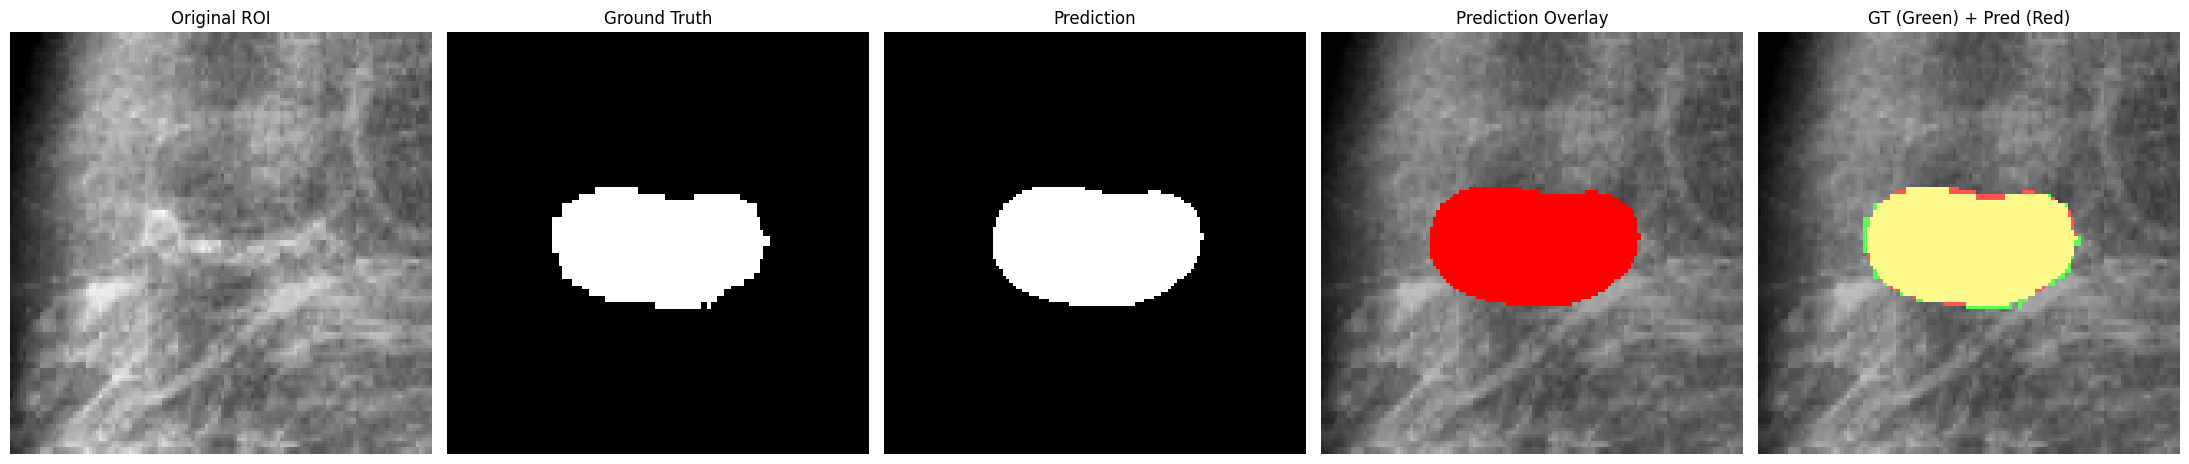

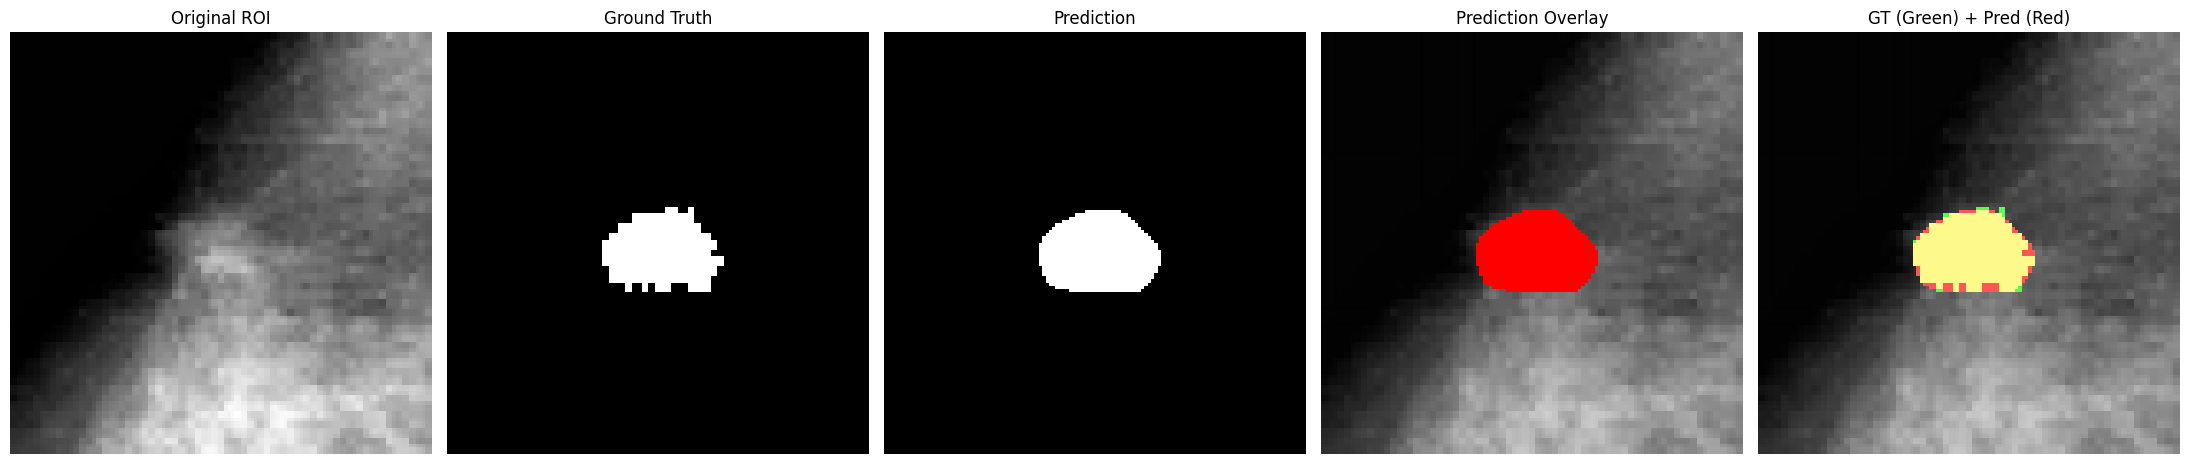

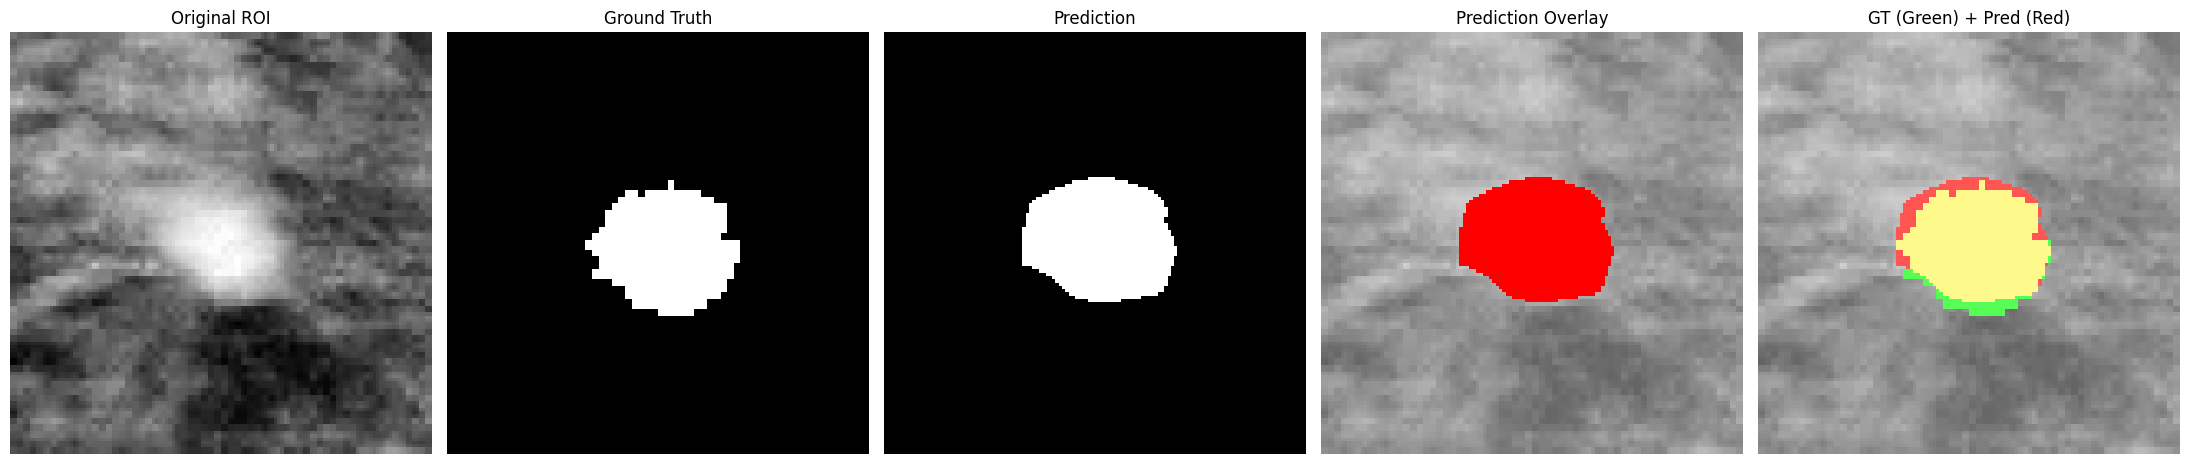

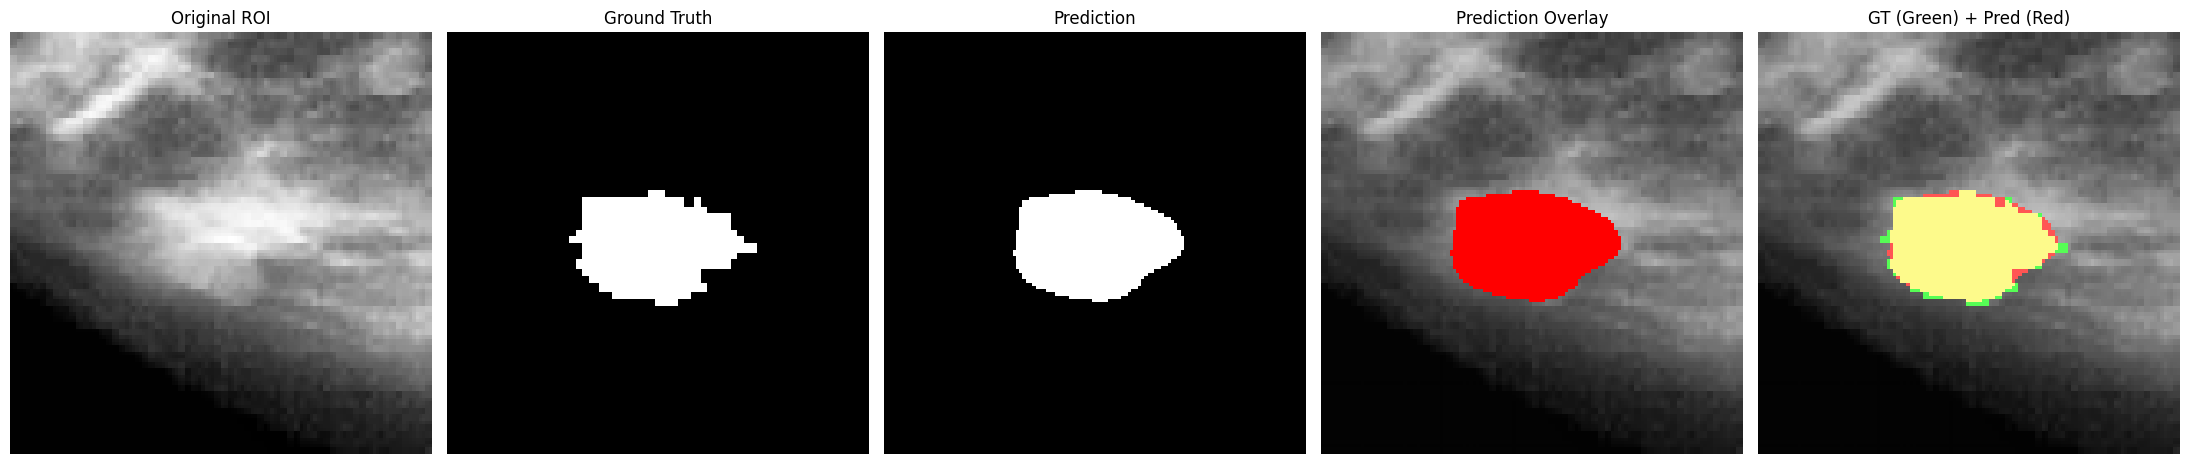

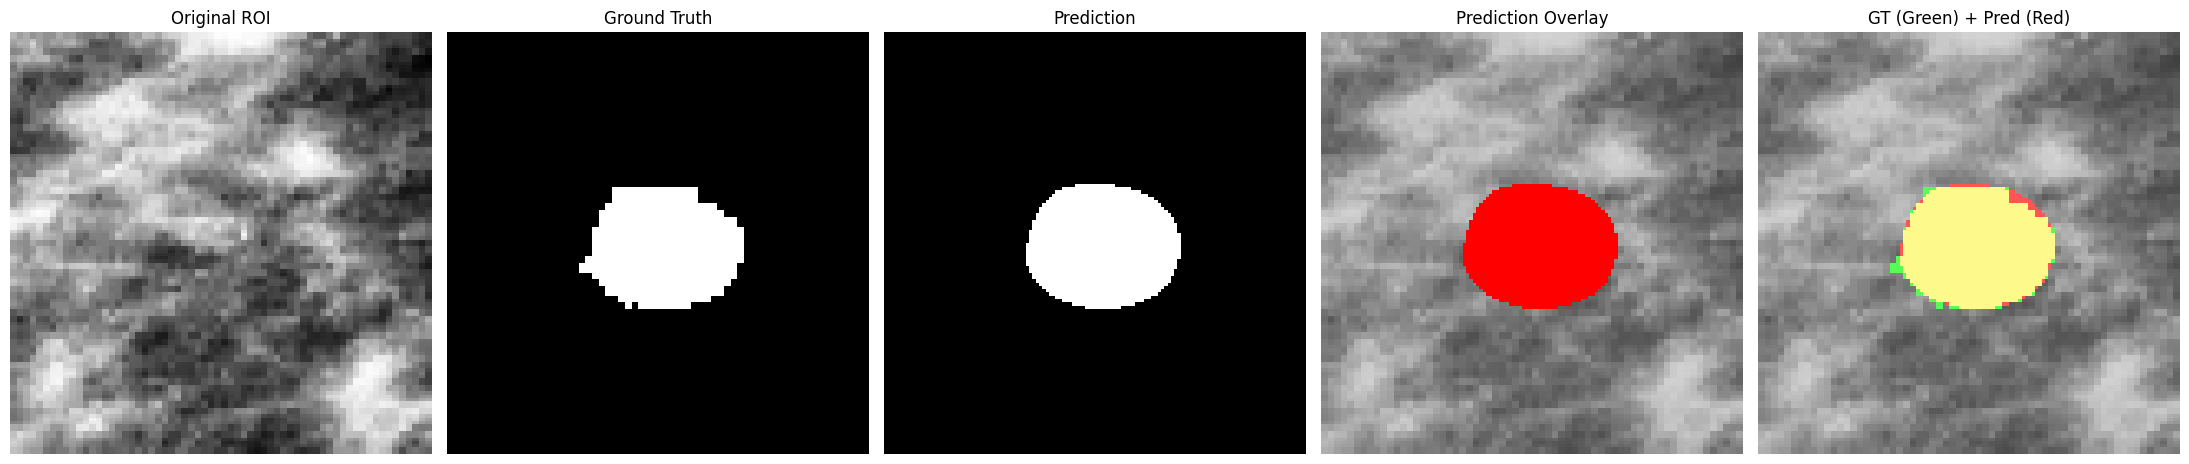

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import random

num_samples = 5
indices = random.sample(range(len(X_test)), num_samples)

for idx in indices:

    img = X_test[idx].squeeze()
    gt = Y_test[idx].squeeze().astype(np.uint8)
    pred = (predictions[idx] > 0).astype(np.uint8)

    plt.figure(figsize=(22,5))

    # Original ROI
    plt.subplot(1,5,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original ROI")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,5,2)
    plt.imshow(gt, cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1,5,3)
    plt.imshow(pred, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    # Prediction Overlay
    # Prediction Overlay (Bright Red)

    overlay = np.dstack([img, img, img]).copy()

# Color prediction in bright red
    overlay[pred == 1] = [1, 0, 0]

    plt.subplot(1,5,4)
    plt.imshow(overlay)
    plt.title("Prediction Overlay")
    plt.axis("off")

    # GT + Prediction Overlay
    # GT + Prediction Overlay (RGB)

    overlay = np.dstack([img, img, img]).copy()

# Ground Truth -> Green
    overlay[gt == 1] = [0, 1, 0]

# Prediction -> Red
    overlay[pred == 1] = [1, 0, 0]

# Overlap -> Yellow
    overlay[(gt == 1) & (pred == 1)] = [1, 1, 0]

    plt.subplot(1,5,5)
    plt.imshow(overlay)
    plt.title("GT (Green) + Pred (Red)")
    plt.axis("off")

    # Ground Truth (Green)
    plt.imshow(
        np.ma.masked_where(gt == 0, gt),
        cmap='Greens',
        alpha=0.35
    )

    # Prediction (Red)
    plt.imshow(
        np.ma.masked_where(pred == 0, pred),
        cmap='Reds',
        alpha=0.35
    )

    plt.title("GT (Green) + Pred (Red)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

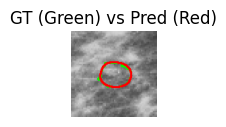

In [39]:
import cv2

plt.subplot(1,5,5)

plt.imshow(img, cmap='gray')

# Find contours
gt_contours, _ = cv2.findContours(
    gt.astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

pred_contours, _ = cv2.findContours(
    pred.astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

# Green = Ground Truth boundary
cv2.drawContours(overlay, gt_contours, -1, (0,255,0), 2)

# Red = Prediction boundary
cv2.drawContours(overlay, pred_contours, -1, (255,0,0), 2)

plt.imshow(overlay)
plt.title("GT (Green) vs Pred (Red)")
plt.axis("off")